In [7]:
import matplotlib.pyplot as plt

In [ ]:
import nltk
nltk.download('stopwords')

In [3]:
from textblob import TextBlob

text = 'Today is a beautiful day. Tomorrow looks like bad weather.'

blob = TextBlob(text)

blob

TextBlob("Today is a beautiful day. Tomorrow looks like bad weather.")

In [4]:
blob.sentences

[Sentence("Today is a beautiful day."),
 Sentence("Tomorrow looks like bad weather.")]

In [5]:
blob.words

WordList(['Today', 'is', 'a', 'beautiful', 'day', 'Tomorrow', 'looks', 'like', 'bad', 'weather'])

In [8]:
blob.tags

[('Today', 'NN'),
 ('is', 'VBZ'),
 ('a', 'DT'),
 ('beautiful', 'JJ'),
 ('day', 'NN'),
 ('Tomorrow', 'NNP'),
 ('looks', 'VBZ'),
 ('like', 'IN'),
 ('bad', 'JJ'),
 ('weather', 'NN')]

In [9]:
blob.noun_phrases

WordList(['beautiful day', 'tomorrow', 'bad weather'])

In [11]:
print(blob.sentiment, blob.sentiment.polarity, blob.sentiment.subjectivity)

Sentiment(polarity=0.07500000000000007, subjectivity=0.8333333333333333) 0.07500000000000007 0.8333333333333333


In [12]:
from textblob.sentiments import NaiveBayesAnalyzer

blob1 = TextBlob("Today is a beautiful day. Tomorrow looks like bad weather.", analyzer=NaiveBayesAnalyzer())

blob1.sentiment

Sentiment(classification='neg', p_pos=0.47662917962091056, p_neg=0.5233708203790892)

In [15]:
from textblob import Word

index = Word('index')

cacti = Word('cacti')

animals = TextBlob('dog cat fish bird').words

print(index.pluralize(), cacti.singularize())

animals.pluralize()

indices cactus


WordList(['dogs', 'cats', 'fish', 'birds'])

You can check a Word’s spelling with its spellcheck method, which returns a list of tuples containing possible correct spellings and a confidence value. Let’s assume we meant to type the word “they” but we misspelled it as “theyr.” The spell checking results show two possible corrections with the word 'they' having the highest confidence value

In [17]:
word = Word('theyr')

word.spellcheck(), word.correct()

([('they', 0.5713042216741622), ('their', 0.42869577832583783)], 'they')

In [19]:
word = Word('varieties')
word.stem(), word.lemmatize()

('varieti', 'variety')

In [23]:
blob.word_counts['day'], blob.words.count('day')

(1, 1)

In [ ]:
happy = Word('happy')

# Print synonyms of word happy
print(happy.synsets)

# Print antonyms of word unhappy
print(happy.synsets[0].lemmas()[0].antonyms())

# Print definitions of happy
happy.definitions

[Synset('happy.a.01'), Synset('felicitous.s.02'), Synset('glad.s.02'), Synset('happy.s.04')]
[Lemma('unhappy.a.01.unhappy')]


['enjoying or showing or marked by joy or pleasure',
 'marked by good fortune',
 'eagerly disposed to act or to be of service',
 'well expressed and to the point']

In [34]:
from nltk.corpus import stopwords

stops = stopwords.words('english')

print([word for word in blob.words if word not in stops])

['Today', 'beautiful', 'day', 'Tomorrow', 'looks', 'like', 'bad', 'weather']


In [36]:
blob.ngrams(n=5)  # default value for n is 3

[WordList(['Today', 'is', 'a', 'beautiful', 'day']),
 WordList(['is', 'a', 'beautiful', 'day', 'Tomorrow']),
 WordList(['a', 'beautiful', 'day', 'Tomorrow', 'looks']),
 WordList(['beautiful', 'day', 'Tomorrow', 'looks', 'like']),
 WordList(['day', 'Tomorrow', 'looks', 'like', 'bad']),
 WordList(['Tomorrow', 'looks', 'like', 'bad', 'weather'])]

(-0.500, 1599.500, 799.500, -0.500)

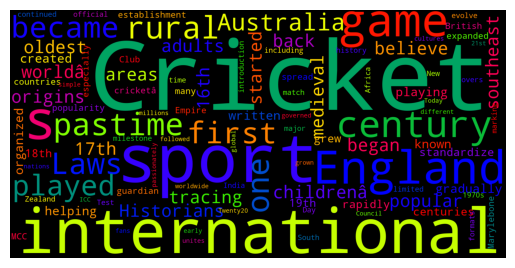

In [8]:
# !pip install wordcloud
from wordcloud import WordCloud

# import imageio

# mask_image = imageio.imread('')

wordcloud1 = WordCloud(colormap='prism', background_color='black', scale=4) 
# no mask is available, set scale > 3 for better image quality

wc = wordcloud1.generate(text)

plt.imshow(wc)
plt.axis("off")

(-0.5, 1599.5, 799.5, -0.5)

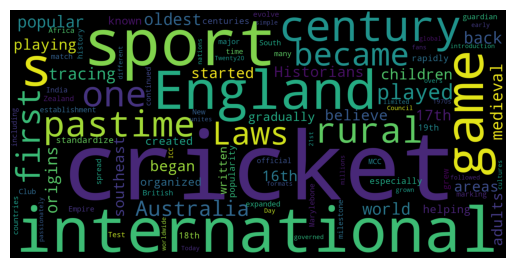

In [26]:
wc2 = WordCloud(background_color='black', scale=4).generate(text) # no mask is available

plt.imshow(wc2)
plt.axis("off")

(-0.500, 399.500, 199.500, -0.500)

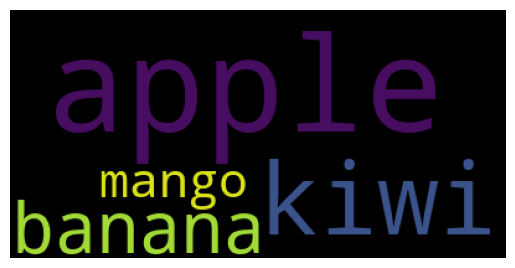

In [12]:
word_freq = {"apple":80, 'banana':30, 'kiwi':39, 'mango':12}
wordcloud3 = WordCloud()
wordcloud3.fit_words(word_freq)
plt.imshow(wordcloud3)
plt.axis('off')

In [14]:
# !pip install textatistic
from textatistic import Textatistic
from pathlib import Path

text = Path('paragraph.txt').read_text()

textinfo = Textatistic(text)

%precision 3

'%.3f'

In [ ]:
from textatistic import Textatistic
textinfo = Textatistic(text)
z = textinfo.dict()
cpw = z['char_count']/z['word_count']
wps = z['word_count']/z['sent_count']
print(z['sybl_count'], z['polysyblword_count'])
print(cpw, wps)

318 20
5.46046511627907 21.5


In [4]:
textinfo.dict()

{'char_count': 1168,
 'word_count': 215,
 'sent_count': 10,
 'sybl_count': 317,
 'notdalechall_count': 77,
 'polysyblword_count': 20,
 'flesch_score': 60.277,
 'fleschkincaid_score': 10.193,
 'gunningfog_score': 12.321,
 'smog_score': 11.208,
 'dalechall_score': 10.358}

In [ ]:
# !pip install spacy
# !python -m spacy download en_core_web_sm

import spacy

spacy_obj = spacy.load('en_core_web_sm')


text = """Cricket is one of the world's oldest and most popular sports, with origins tracing back to medieval England. Historians believe the game began as a children's pastime in the rural areas of southeast England during the 16th century. By the 17th century, adults had started playing it, and the sport gradually became more organized. In 1744, the first known written Laws of Cricket were created, helping standardize how the game was played. During the 18th and 19th centuries, cricket grew rapidly in popularity, especially with the establishment of the Marylebone Cricket Club (MCC) in 1787, which became the guardian of cricket's laws. As the British Empire expanded, cricket spread to many countries including India, Australia, South Africa, and New Zealand. The first official international Test match was played in 1877 between England and Australia, marking a major milestone in cricket history. Over time, the sport continued to evolve with the introduction of limited-overs formats such as One Day Internationals in the 1970s and Twenty20 cricket in the early 21st century. Today, international cricket is governed by the International Cricket Council (ICC), and the game is followed passionately by millions of fans worldwide. Cricket has grown from a simple rural pastime into a global sport that unites different cultures and nations through competition and sportsmanship.
"""

text_n = """Cricket stands as one of the world's oldest and most beloved sports, originating in medieval England where it began as a children's pastime in the rural southeast during the 16th century. By the 17th century, adults embraced it, leading to greater organization, and in 1744, the first written Laws of Cricket standardized the game. The Marylebone Cricket Club (MCC), established in 1787, became the custodian of these laws, propelling cricket's surge in popularity through the 18th and 19th centuries. As the British Empire expanded, the sport spread to countries like India, Australia, South Africa, and New Zealand, culminating in the first official Test match between England and Australia in 1877. It continued evolving with limited-overs formats like One Day Internationals in the 1970s and Twenty20 in the early 2000s, now governed globally by the International Cricket Council (ICC) and passionately followed by millions, uniting diverse cultures through competition and sportsmanship.
"""
document1 = spacy_obj(text)
document2 = spacy_obj(text_n)

In [8]:
for item in document1.ents:
    print(item.text, item.label_)

England GPE
southeast England LOC
the 16th century DATE
the 17th century DATE
1744 DATE
first ORDINAL
Laws of Cricket ORG
the 18th and 19th centuries DATE
the Marylebone Cricket Club ORG
1787 DATE
British Empire GPE
India GPE
Australia GPE
South Africa GPE
New Zealand GPE
first ORDINAL
1877 DATE
England GPE
Australia GPE
the 1970s DATE
the early 21st century DATE
Today DATE
the International Cricket Council ORG
millions CARDINAL
Cricket ORG


In [ ]:
print(document1.similarity(document2))

0.942756905679949


NLP Tools

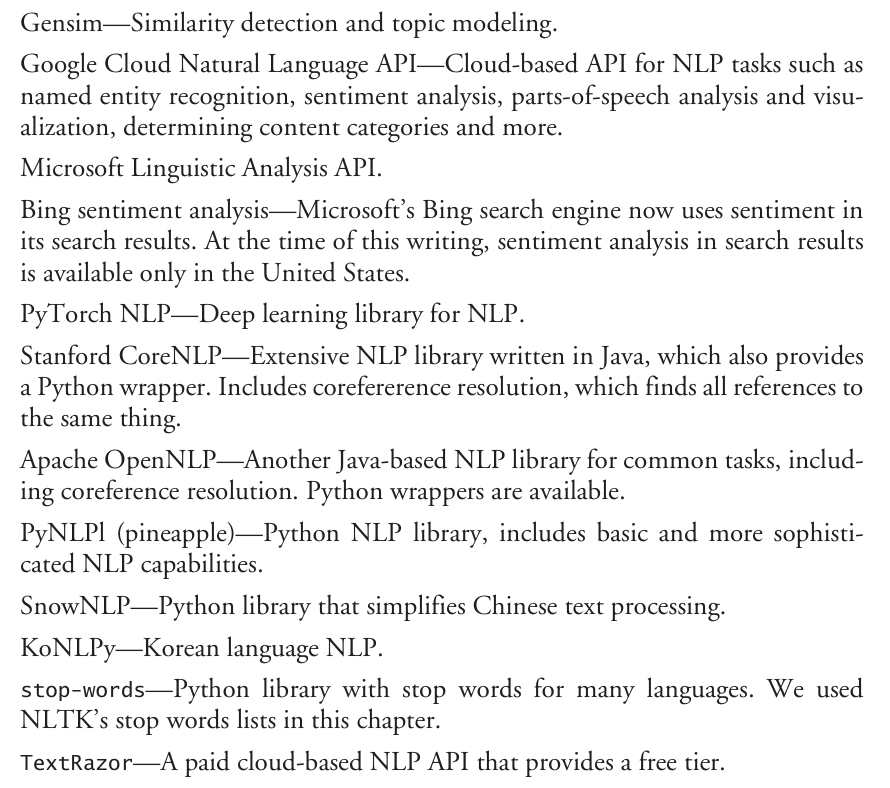

Machine Learning and Deep Learning NLP Applications
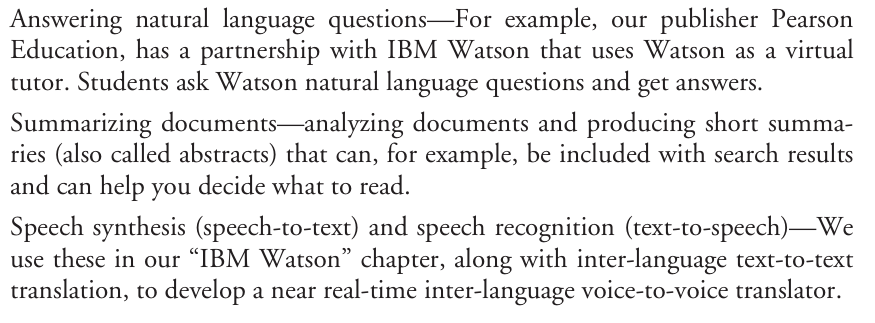
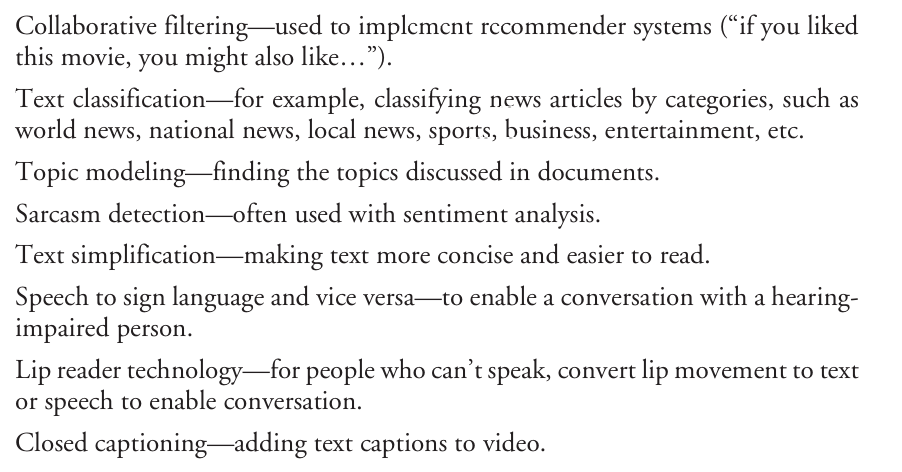

List of NLP Datasets

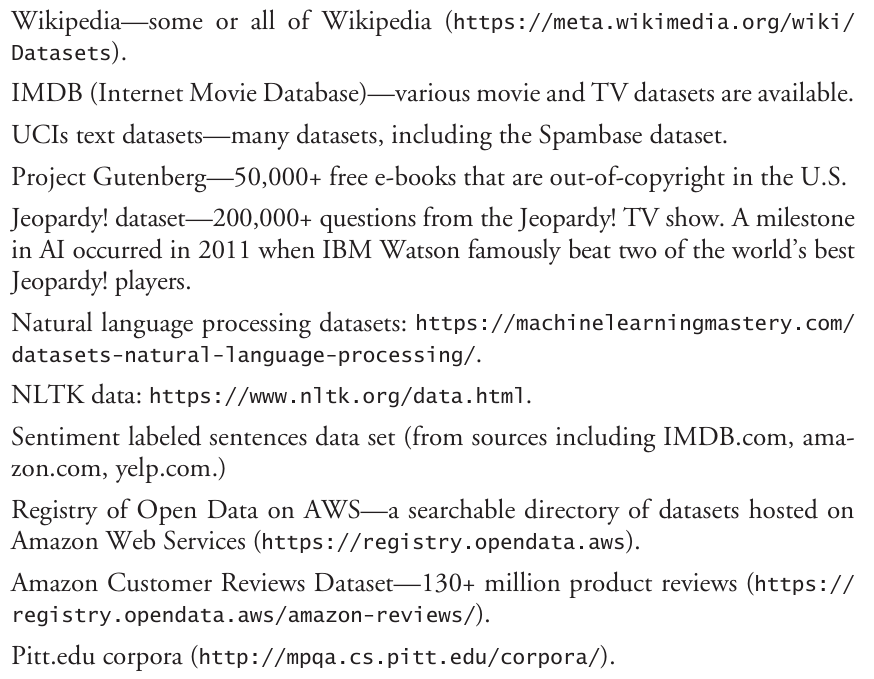